In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
#load data
df = pd.read_csv('/Users/beza/code/bezawitzyb/noshowshield/raw_data/hotel_bookings.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 119,390 rows × 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [11]:
profile = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
    'sample_value': df.iloc[0]
})
profile.sort_values('null_pct', ascending=False)

,dtype,non_null,null_count,null_pct,n_unique,sample_value
company,float64,6797,112593,94.31,352,NaN
agent,float64,103050,16340,13.69,333,NaN
country,object,118902,488,0.41,177,PRT
hotel,object,119390,0,0.00,2,Resort Hotel
previous_cancellations,int64,119390,0,0.00,15,0
reservation_status,object,119390,0,0.00,3,Check-Out
total_of_special_requests,int64,119390,0,0.00,6,0
required_car_parking_spaces,int64,119390,0,0.00,5,0
adr,float64,119390,0,0.00,8879,0.0
customer_type,object,119390,0,0.00,4,Transient


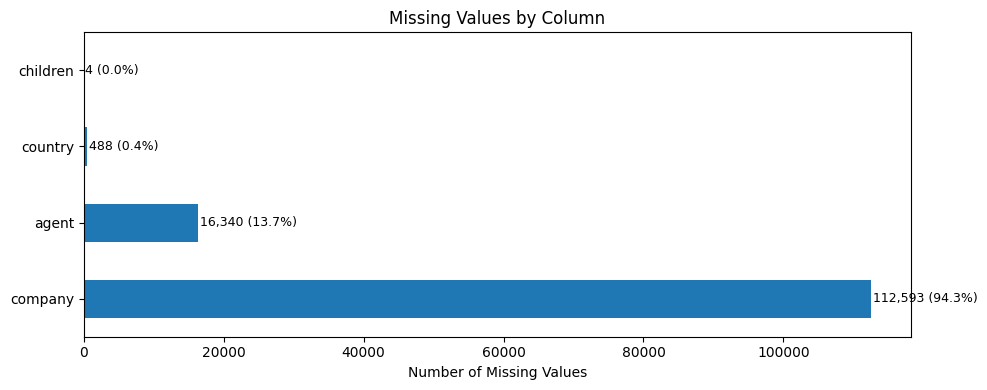

In [13]:
# Visualise missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing.plot(kind='barh', ax=ax)
    ax.set_title('Missing Values by Column')
    ax.set_xlabel('Number of Missing Values')
    for i, v in enumerate(missing):
        ax.text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [14]:
df.duplicated().any()

np.True_

In [15]:
df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,No Deposit,9.0,NaN,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,No Deposit,9.0,NaN,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [17]:
df = df.drop_duplicates()

In [18]:
companies = df[df['company'].notna()]

In [24]:
companies.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,NaN,110.0,0,Transient,107.42,0,0,Check-Out,2015-07-02
218,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,NaN,110.0,0,Transient,104.72,0,1,Canceled,2015-07-08
220,Resort Hotel,0,1,2015,July,28,8,0,2,2,...,No Deposit,NaN,110.0,0,Transient,104.72,1,1,Check-Out,2015-07-10
295,Resort Hotel,0,84,2015,July,28,11,1,1,2,...,No Deposit,NaN,113.0,0,Transient,100.00,1,0,Check-Out,2015-07-13
387,Resort Hotel,0,1,2015,July,29,14,0,1,1,...,No Deposit,NaN,270.0,0,Transient,134.00,0,0,Check-Out,2015-07-15
450,Resort Hotel,1,12,2015,July,29,16,2,3,2,...,No Deposit,NaN,178.0,0,Transient,139.00,0,0,Canceled,2015-07-07
541,Resort Hotel,0,0,2015,July,30,19,1,0,2,...,No Deposit,NaN,240.0,0,Group,88.20,0,0,Check-Out,2015-07-20
600,Resort Hotel,0,5,2015,July,30,21,0,2,1,...,No Deposit,NaN,154.0,0,Transient,99.50,0,0,Check-Out,2015-07-23
628,Resort Hotel,1,19,2015,July,30,23,1,3,2,...,No Deposit,NaN,178.0,0,Transient,139.00,0,0,Canceled,2015-07-07
796,Resort Hotel,1,0,2015,July,31,30,0,1,1,...,No Deposit,NaN,270.0,0,Transient,114.00,0,0,Canceled,2015-07-30
